Diamonds - сравнение регрессионных моделей

**Цель:** системно сравнить разные классы моделей регрессии (линейные модели, дерево решений, ансамбли и бустинг) и объяснить различия в их поведении.

**Задача:** предсказать цену бриллианта (`price`).

Важно:
- Все модели обучаются на train. Метрики необходимо показать как на train, так и на test. Это позволит понять где насколько мы переобучились.
- Сплит менять нельзя
- Главная цель — не выбить максимум, а понять различия моделей (ведь все мы знаем кто победит...)


---

## 1) Краткий анализ данных

1. Размер датасета  
2. Типы признаков  
3. Есть ли пропуски?  
4. Распределение целевой переменной  

Коротко (3–5 строк):

- выглядит ли задача линейной?
- есть ли признаки возможной нелинейности?
- ожидаете ли вы, что линейная модель будет достаточной? почему?

---

## 2) Линейная модель

Обучите:
- `LinearRegression`  
или  
- `Ridge` (с подбором `alpha`).

> Ridge-регрессия не разбиралась подробно на семинаре, но можно понять что это такое по доп материалам из чата на соответствующей неделе.

Требования:
- корректная обработка категориальных признаков
- масштабирование при необходимости
- аккуратный расчёт метрик

Оцените на test:
- RMSE  
- MAE  
- R²  

Письменно (4–6 строк):

- в чём ограничения линейной модели в этой задаче?
- какие идеи (не ансамбли!) могли бы улучшить её качество?

---

## 3) Decision Tree Regressor

Обучите `DecisionTreeRegressor`.

Подберите с помощью любого знакомого метода (GridSearch / RandomSearch / Optuna и т.д.):

- `max_depth`
- `min_samples_leaf`

Обязательно покажите:
- качество на train
- качество на test

Ответьте:

- есть ли переобучение?
- можно ли избавиться от переобучения просто увеличивая глубину? почему?

---

## 4) Ансамбли

### 4.1 Bagging Regressor

Обучите `BaggingRegressor` на базе деревьев.

Подберите:
- `n_estimators`
- глубину базового дерева

Сравните с одиночным деревом:

- что изменилось в метриках?
- уменьшился ли разрыв между train и test?
- почему?

---

### 4.2 Random Forest

Обучите `RandomForestRegressor`.

Подберите:
- `n_estimators`
- `max_depth`
- `max_features`

Ответьте:

- чем RF принципиально отличается от обычного Bagging?
- что даёт случайный выбор признаков?
- как меняется разрыв между train и test при росте глубины? почему?

---

### 4.3 CatBoostRegressor

Обучите `CatBoostRegressor`. Используйте встроенную обработку категориальных признаков.

Подберите:
- `depth`
- `learning_rate`
- `iterations` (можно с early stopping)

Сравните с Random Forest.

Ответьте:

- за счёт чего бустинг может выигрывать?
- есть ли признаки переобучения?
- в чём фундаментальное отличие бустинга от bagging-подходов?

---

## 5) Итоговое сравнение

Сведите результаты в таблицу:

| Модель | RMSE (train) | RMSE (test) | MAE (test) | R² (test) |

Письменно (5–8 строк):

1. Какая модель лучшая?
2. Насколько велика разница между RF и CatBoost?
3. Где линейная модель проигрывает сильнее всего?
4. Что в этой задаче играет большую роль:
   - нелинейность?
   - ансамблирование?
   - взаимодействия признаков?

Аргументируйте, не просто перечисляйте.

In [1]:
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = sns.load_dataset("diamonds")

X = df.drop(columns="price")
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

df.shape, X_train.shape, X_test.shape

((53940, 10), (43152, 9), (10788, 9))

---
## 1) Краткий анализ данных

Размер датасета:

In [3]:
df.shape

(53940, 10)

53940 - строк, 10 - столбцов

In [4]:
df.dtypes

carat       float64
cut        category
color      category
clarity    category
depth       float64
table       float64
price         int64
x           float64
y           float64
z           float64
dtype: object

Атрибут dtypes возвращает типы данных в каждом из столбцов

In [5]:
df.nunique()

carat        273
cut            5
color          7
clarity        8
depth        184
table        127
price      11602
x            554
y            552
z            375
dtype: int64

In [6]:
df.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

В данных пропусков нет

In [7]:
y = df['price']

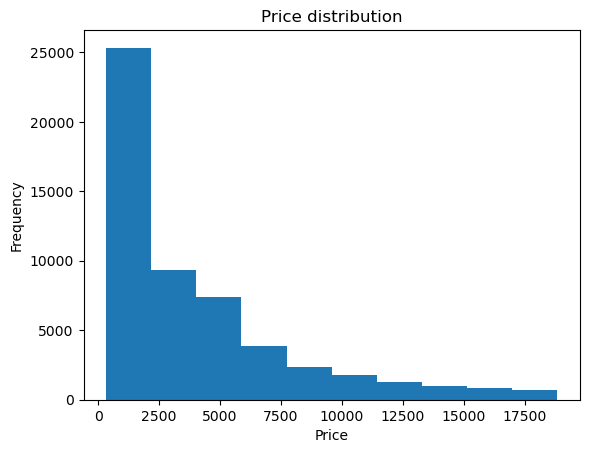

In [8]:
import matplotlib.pyplot as plt

plt.hist(y)
plt.title('Price distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

Распределение цен имеет выраженную правостороннюю асимметрию. Основная масса товаров сосредоточена в диапазоне до 2500, после чего с увеличением цены частота наблюдений постепенно снижается. Наблюдается длинный правый хвост, что указывает на наличие относительно небольшого количества дорогих товаров.

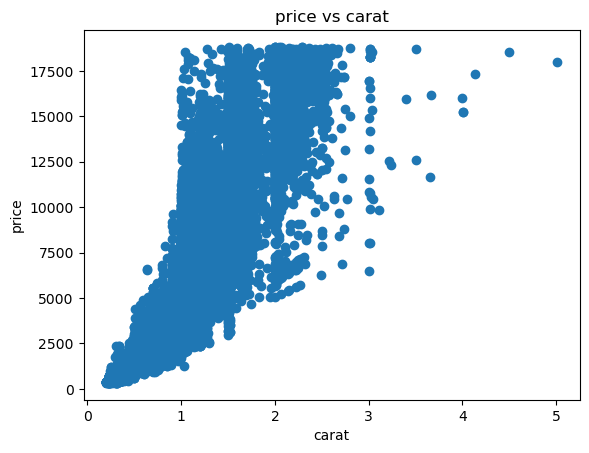

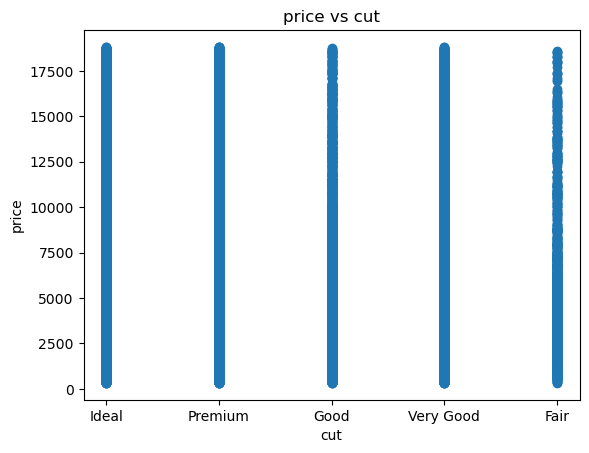

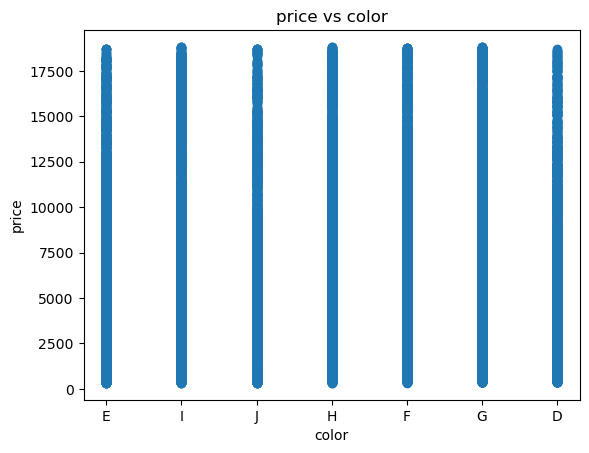

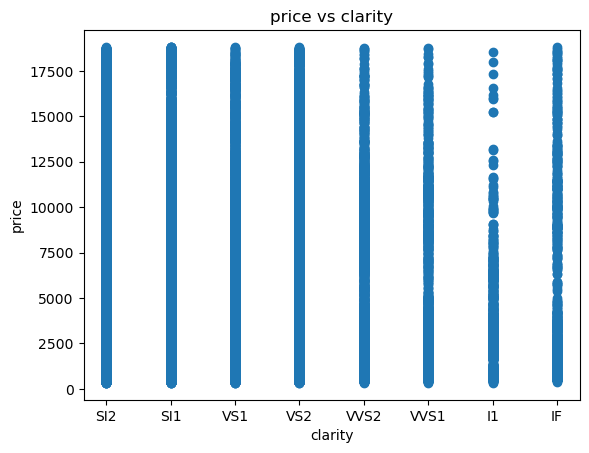

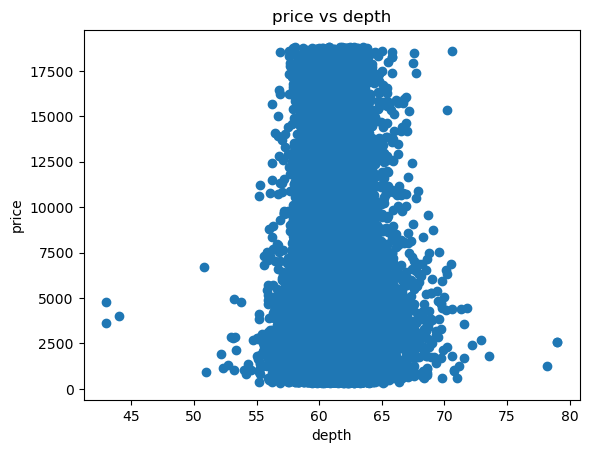

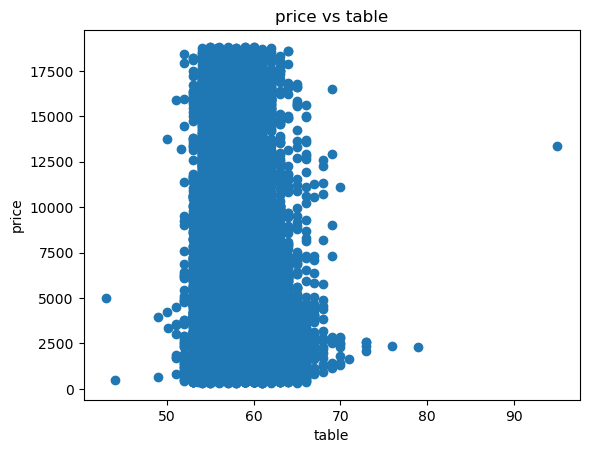

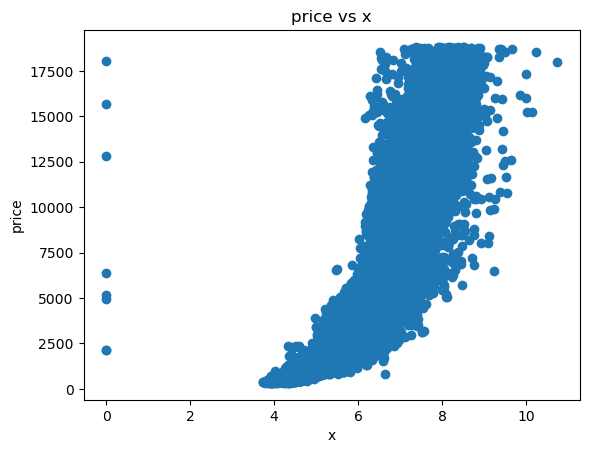

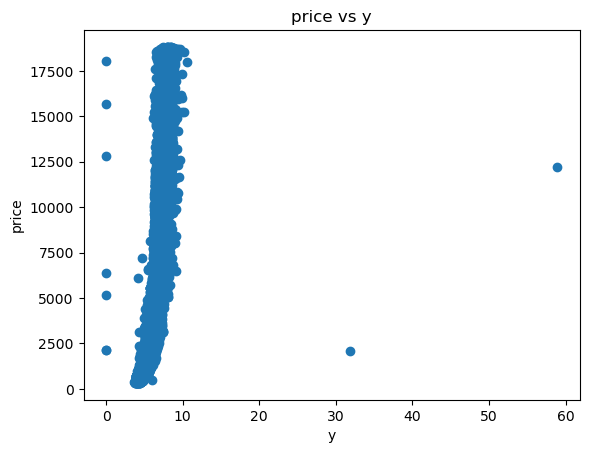

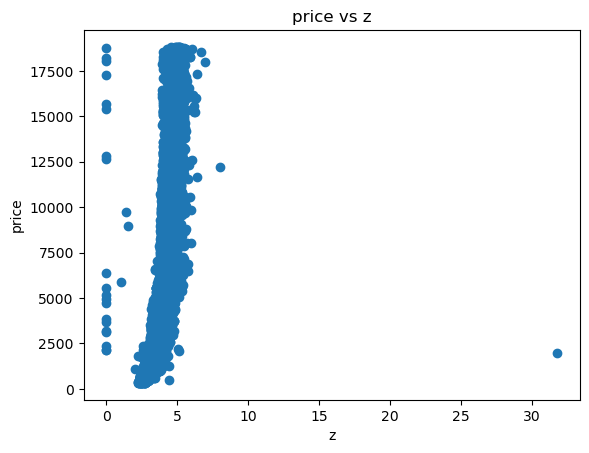

In [9]:
features = df.drop(columns=['price']).columns

for col in features:
    plt.figure()
    plt.scatter(df[col], df['price'])
    plt.xlabel(col)
    plt.ylabel('price')
    plt.title(f'price vs {col}')
    plt.show()

Задача **не выглядит линейной** из-за графиков зависимостей price от признаков.

По графиком видно, что от признака carat у target выражена явная степенная зависимость. Она наблюдается и у признака x, в меньшей степени у z и y. От остальных признаков target не выражает явной зависимости. Так что **присутствуют признаки возможной нелинейности**. 

Нет, я **не ожидаю что линейной модели будет достаточно**, потому что явной линейной зависимости ни в одном из признаков нет.

---
## 2) Линейная модель

In [11]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
import numpy as np

Выбираем столбцы с непрерывными и категориалными признаками:

In [12]:
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns
num_cols = X_train.select_dtypes(include=['number']).columns

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols), # масштабируем
    ],
    remainder='drop' # это что делать с колонками, которые НЕ перечислены в transformers - удалить всё лишнее
)

In [14]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0))
])

model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Функция для **ошибок**.

In [15]:
def regression_report(model, X, y, name):
    pred = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y, pred))
    mae = mean_absolute_error(y, pred)
    r2 = r2_score(y, pred)
    print(f"{name} RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")
    return rmse, mae, r2

In [16]:
print("\n=== Train ===")
train_metrics_r = regression_report(model, X_train, y_train, "Train")

print("\n=== Test ===")
test_metrics_r = regression_report(model, X_test, y_test, "Test")


=== Train ===
Train RMSE: 1128.5874 | MAE: 741.8374 | R2: 0.9200

=== Test ===
Test RMSE: 1135.1914 | MAE: 736.7118 | R2: 0.9189


- в чём ограничения линейной модели в этой задаче?
- какие идеи (не ансамбли!) могли бы улучшить её качество?
  
Линейная модель предполагает линейную зависимость между признаками и целевой переменной, тогда как в данной задаче наблюдается выраженная нелинейная зависимость цены от carat и размеров. Кроме того, разброс ошибок увеличивается при росте carat. Линейная модель также не учитывает возможные взаимодействия признаков (например, carat × clarity). Улучшить качество можно с помощью логарифмирования целевой переменной, добавления полиномиальных признаков и более аккуратной настройки коэффициента регуляризации.

---
## 3) Decision Tree Regressor

In [17]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

In [18]:
pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

param_grid = {
    'regressor__max_depth': [None, 3, 5, 7, 10, 15, 20, 30],
    'regressor__min_samples_leaf': [1, 2, 5, 10, 20, 50, 100],
}

gs = GridSearchCV(
    estimator=pipe, # какую модель (pipeline) будем подбирать
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',  # по какой метрике оцениват
    cv=5, # 5-fold кросс-валидация
    n_jobs=-1, # ипользуем все ядра
    verbose=1 # пишет общее кол-во fit (инцормация об обучении)
)

gs.fit(X_train, y_train)

print("Best params:", gs.best_params_)
print("Best RMSE:", -gs.best_score_)

best_model = gs.best_estimator_

print("\n=== Train ===")
train_metrics_dt = regression_report(best_model, X_train, y_train, "Train")

print("\n=== Test ===")
test_metrics_dt = regression_report(best_model, X_test, y_test, "Test")

Fitting 5 folds for each of 56 candidates, totalling 280 fits
Best params: {'regressor__max_depth': 20, 'regressor__min_samples_leaf': 5}
Best RMSE: 784.8536161376103

=== Train ===
Train RMSE: 460.5571 | MAE: 222.8879 | R2: 0.9867

=== Test ===
Test RMSE: 798.0132 | MAE: 361.9347 | R2: 0.9599


- есть ли переобучение?
- можно ли избавиться от переобучения просто увеличивая глубину? почему?

По результатам видно, что качество на обучающей выборке существенно выше, чем на тестовой (особенно по RMSE и MAE), что указывает на **наличие переобучения**. Несмотря на то, что гиперпараметры подбирались по метрике RMSE с помощью кросс-валидации, модель остаётся более точной на train, чем на test. **Увеличение глубины дерева не помогает избавиться от переобучения**, поскольку более глубокое дерево становится более сложным, увеличивает variance и начинает запоминать шум обучающей выборки. Для уменьшения переобучения необходимо ограничивать глубину дерева и увеличивать минимальное число объектов в листе.

---
## Ансамбли
### 4.1 Bagging Regressor

In [19]:
from sklearn.ensemble import BaggingRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

In [20]:
base_tree = DecisionTreeRegressor(random_state=42)

bag_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', BaggingRegressor(
        estimator=base_tree,
        random_state=42,
        n_jobs=-1
    ))
])

bag_param_dist = {
    "regressor__n_estimators": randint(50, 120), # кол-во деревьев в ансамбле
    "regressor__estimator__max_depth": randint(3, 15), # ограничение в глубину
    "regressor__estimator__min_samples_leaf": randint(1, 10) # мин кол-во элементов в листьях
}

bag_rs = RandomizedSearchCV(
    estimator=bag_pipe,
    param_distributions=bag_param_dist,
    n_iter=15,   # сколько случайных комбинаций попробовать
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

bag_rs.fit(X_train, y_train)

print("\n[Bagging RandomSearch] Best params:", bag_rs.best_params_)
print("[Bagging RandomSearch] Best CV RMSE:", -bag_rs.best_score_)

best_bag = bag_rs.best_estimator_

print("\n=== Bagging: Train ===")
bag_train = regression_report(best_bag, X_train, y_train, "Train")
print("=== Bagging: Test ===")
bag_test = regression_report(best_bag, X_test, y_test, "Test")

Fitting 3 folds for each of 15 candidates, totalling 45 fits

[Bagging RandomSearch] Best params: {'regressor__estimator__max_depth': 14, 'regressor__estimator__min_samples_leaf': 5, 'regressor__n_estimators': 82}
[Bagging RandomSearch] Best CV RMSE: 711.2744734860407

=== Bagging: Train ===
Train RMSE: 554.9009 | MAE: 270.2578 | R2: 0.9807
=== Bagging: Test ===
Test RMSE: 694.1723 | MAE: 329.0158 | R2: 0.9697


* что изменилось в метриках?
* уменьшился ли разрыв между train и test?
* почему?

По сравнению с одиночным деревом решений качество модели на тестовой выборке улучшилось: значения RMSE и MAE уменьшились, а R² увеличился. Разрыв между метриками на обучающей и тестовой выборках стал меньше, что свидетельствует о снижении степени переобучения. Это объясняется тем, что BaggingRegressor обучает несколько деревьев на разных бутстрэп-выборках и усредняет их предсказания. Усреднение уменьшает variance модели, благодаря чему она становится более стабильной и лучше обобщает данные.

### 4.2 Random Forest

In [21]:
from sklearn.ensemble import RandomForestRegressor

In [22]:
rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))
])

rf_param_dist = {
    "regressor__n_estimators": [50, 100, 150, 200],
    "regressor__max_depth": [5, 10, 15, 20, None],
    "regressor__max_features": ["sqrt", "log2", 0.5, 0.8]
}

rf_rs = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=rf_param_dist,
    n_iter=15,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_rs.fit(X_train, y_train)

print("\n[Random Forest] Best params:", rf_rs.best_params_)
print("[Random Forest] Best CV RMSE:", -rf_rs.best_score_)

best_rf = rf_rs.best_estimator_

print("\n=== Random Forest: Train ===")
rf_train = regression_report(best_rf, X_train, y_train, "Train")

print("\n=== Random Forest: Test ===")
rf_test = regression_report(best_rf, X_test, y_test, "Test")

Fitting 3 folds for each of 15 candidates, totalling 45 fits

[Random Forest] Best params: {'regressor__n_estimators': 200, 'regressor__max_features': 'sqrt', 'regressor__max_depth': None}
[Random Forest] Best CV RMSE: 721.4617847840054

=== Random Forest: Train ===
Train RMSE: 252.3913 | MAE: 120.6832 | R2: 0.9960

=== Random Forest: Test ===
Test RMSE: 670.0434 | MAE: 324.1018 | R2: 0.9718


- чем RF принципиально отличается от обычного Bagging?
- что даёт случайный выбор признаков?
- как меняется разрыв между train и test при росте глубины? почему?

По сравнению с Bagging модель Random Forest показала более высокое качество на тестовой выборке: RMSE уменьшился (с 694 до 670), MAE также снизился, а R² увеличился (с 0.9697 до 0.9718). Это говорит о том, что Random Forest лучше обобщает данные. Однако при этом качество на обучающей выборке стало практически идеальным (R² = 0.9960), а разрыв между train и test снова увеличился по сравнению с Bagging (примерно 0.024 против 0.011). Это связано с тем, что при отсутствии ограничения глубины деревья становятся очень сложными и уменьшают bias, но увеличивают variance. Несмотря на это, случайный выбор признаков в Random Forest снижает корреляцию между деревьями и позволяет модели показывать более устойчивые и точные результаты по сравнению с обычным Bagging.


### 4.3 CatBoostRegressor 

In [27]:
from catboost import CatBoostRegressor, Pool

In [30]:
model_cb = CatBoostRegressor(
    loss_function='RMSE',  
    eval_metric='RMSE',     
    random_seed=42,
    verbose=0
)


param_dist = {
    'depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'iterations': [300, 500, 800]
}


cb_rs = RandomizedSearchCV(
    estimator=model_cb,
    param_distributions=param_dist,
    n_iter=5,                         
    scoring='neg_root_mean_squared_error',
    cv=2,                             
    random_state=42,
    n_jobs=-1,
    verbose=1
)

cb_rs.fit(X_train, y_train, cat_features=list(cat_cols))

print("Best params:", cb_rs.best_params_)
print("Best CV RMSE:", -cb_rs.best_score_)

best_model_cb = cb_rs.best_estimator_

print("\n=== CatBoost: Train ===")
cb_train_metrics = regression_report(best_model_cb, X_train, y_train, "Train")

print("\n=== CatBoost: Test ===")
cb_test_metrics = regression_report(best_model_cb, X_test, y_test, "Test")

Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best params: {'learning_rate': 0.1, 'iterations': 800, 'depth': 4}
Best CV RMSE: 554.0398146053849

=== CatBoost: Train ===
Train RMSE: 493.3443 | MAE: 273.8824 | R2: 0.9847

=== CatBoost: Test ===
Test RMSE: 529.4752 | MAE: 281.7468 | R2: 0.9824


- за счёт чего бустинг может выигрывать?
- есть ли признаки переобучения?
- в чём фундаментальное отличие бустинга от bagging-подходов?

Бустинг выигрывает **за счёт последовательного обучения**: каждое новое дерево исправляет ошибки предыдущих, что снижает bias и позволяет лучше аппроксимировать сложные зависимости.

По метрикам **сильного переобучения не наблюдается**: разрыв между train и test небольшой, а подбор гиперпараметров по кросс-валидации снижает риск переобучения и помогает выбрать устойчивую конфигурацию.

**Фундаментальное отличие** в том, что bagging уменьшает variance за счёт усреднения независимых моделей, а бустинг последовательно снижает bias, обучая модели с учётом предыдущих ошибок.

---
## 5) Итоговое сравнение

In [31]:
results = pd.DataFrame({
    "Модель": [
        "Ridge",
        "Decision Tree",
        "Bagging",
        "Random Forest",
        "CatBoost"
    ],
    "RMSE (train)": [
        train_metrics_r[0],
        train_metrics_dt[0],
        bag_train[0],
        rf_train[0],
        cb_train_metrics[0]
    ],
    "RMSE (test)": [
        test_metrics_r[0],
        test_metrics_dt[0],
        bag_test[0],
        rf_test[0],
        cb_test_metrics[0]
    ],
    "MAE (test)": [
        test_metrics_r[1],
        test_metrics_dt[1],
        bag_test[1],
        rf_test[1],
        cb_test_metrics[1]
    ],
    "R² (test)": [
        test_metrics_r[2],
        test_metrics_dt[2],
        bag_test[2],
        rf_test[2],
        cb_test_metrics[2]
    ]
})

results.round(3)

,Модель,RMSE (train),RMSE (test),MAE (test),R² (test)
0,Ridge,1128.587,1135.191,736.712,0.919
1,Decision Tree,460.557,798.013,361.935,0.960
2,Bagging,554.901,694.172,329.016,0.970
3,Random Forest,252.391,670.043,324.102,0.972
4,CatBoost,493.344,529.475,281.747,0.982


Лучшей моделью является **CatBoost**, так как он показывает наименьший RMSE и MAE на тестовой выборке и наибольший R² (0.982), при этом разрыв между train и test минимален, что говорит о хорошем обобщении. 

**Разница между Random Forest и CatBoost** заметна: RMSE у CatBoost ниже примерно на 150 единиц, а R² выше на 0.01, что для уже высоких значений метрик является существенным улучшением.

**Линейная модель (Ridge) проигрывает** сильнее всего по величине ошибки: её RMSE почти в два раза выше, чем у CatBoost, что говорит о неспособности адекватно описать зависимость цены от признаков. Это связано с выраженной нелинейной зависимостью цены от carat и размеров.

В данной задаче **наибольшую роль** играет именно нелинейность и взаимодействия признаков, поскольку ансамблевые методы, особенно бустинг, способны моделировать сложные зависимости и автоматически учитывать взаимодействия. Ансамблирование дополнительно снижает variance, но ключевой выигрыш достигается за счёт способности моделей описывать сложную нелинейную структуру данных.